# Binary Autoencoder (Hopfield Network)

# Overview
This Jupyter notebook goes through a simple simulation of the Hopfield Network, a fully-connected single layer autoencoding neural network, using plain matrix operations. We will evaluate how this network works by applying it to encode and retrieve different tokens.

# Define the problem
We start as usual, by defining the specific aims that we have. In the present case, it is:

# Instantiating content-addressable memory *in silico*
- Computer hard disks or other similar hardware systems encode token information using indexed memory. This means that the token encoding occupies a specific physical position in the hardware, and this position is retrieved by an arbitrary address. *For instance, storing the word "cat" in position 1 of the hard disk and the word "dog" in position 2 of the hard disk, is equivalent to storing "cat" in position 2 and "dog" in position 1.* The memory content and the position are independent.

- By contrast, biological neural network functioning and our psychological experiences tend to reflect more content-addressable memory. In this case, token encoding and the physical state or location of the encoding are non-arbitrary and in fact equivalent. Thus, altering the position of encoding activity alters the memory content itself.

- A key feature of content-addressable memory is the capacity for retrieval from partial traces. *That is, one can retrieve "cat" based on a cue "c** and mouse".* Several other cool properties and implications ensue.

- The central aim of this project is to determine if an artificial neural network based on machine algorithms, can also instantiate content-addressable memory, albeit in software.

- John Hopfield, a Professor of Physics at Princeton University, received the 2024 Nobel Prize in Physics for exactly working on the above problem. We will attempt to replicate some of his work as published in [[1]](#1).

**References**

1. <a id="1"></a>Hopfield, J. J. (1982). Neural networks and physical systems with emergent collective computational abilities. Proceedings of the National Academy of Sciences USA, *79*, 2554-2558.[[pdf]](https://cool.ntu.edu.tw/files/6932464/download?download_frd=1)

2. *This is the Gitlab repo of my unpublished brief work on the Hopfield Network implementation to test the repetition effect.* Goh, J. (2007). Hopfield Network. *Unpublished*. [[git]](https://gitlab.com/joshuagoh/hopfield-network)

---

# Data table
Train network to recognize different [Walsh functions](https://en.wikipedia.org/wiki/Walsh_function). This means, if we provide some form of the partial or full input, we want to retrieve the output.

| Input | Retrieval | Output |
| ---| --- | --- |
|1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0|--->|1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0|
|1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0|--->|1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0|
|1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0|--->|1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0|
|1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0|--->|1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0|

Let's visualize the above.

Walsh Functions


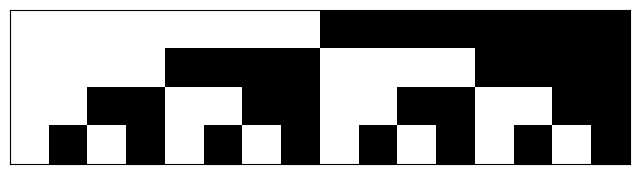

In [ ]:
# prompt: Plot binary vectors as rows of black and white heatmaps

import matplotlib.pyplot as plt
import numpy as np

def plot_binary_vectors_as_heatmap(binary_vectors):
  """Plots binary vectors as rows of black and white heatmaps.

  Args:
    binary_vectors: A list of binary vectors (lists or numpy arrays)
                    where 0 represents white and 1 represents black.
  """
  num_vectors = len(binary_vectors)
  vector_length = len(binary_vectors[0])

  heatmap_data = np.array(binary_vectors)

  plt.figure(figsize=(vector_length / 2, num_vectors / 2))
  plt.imshow(heatmap_data, cmap='gray', aspect='auto')
  plt.xticks([])
  plt.yticks([])
  plt.show()

# Example usage:
binary_vectors = [
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0],
    [1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
]

print("Walsh Functions")
plot_binary_vectors_as_heatmap(binary_vectors)


# Hypothesis
A Hopfield Network can exhibit content-addressable memory as we experience psychologically. A test of this is if the network can retrieve the full trace based on partial input, i.e., content-addressability.

# Aim
- Make a 16-unit Hopfield network that retrieves Walsh functions based on partial input.
___

# Simulation 1

## Visualize architecture

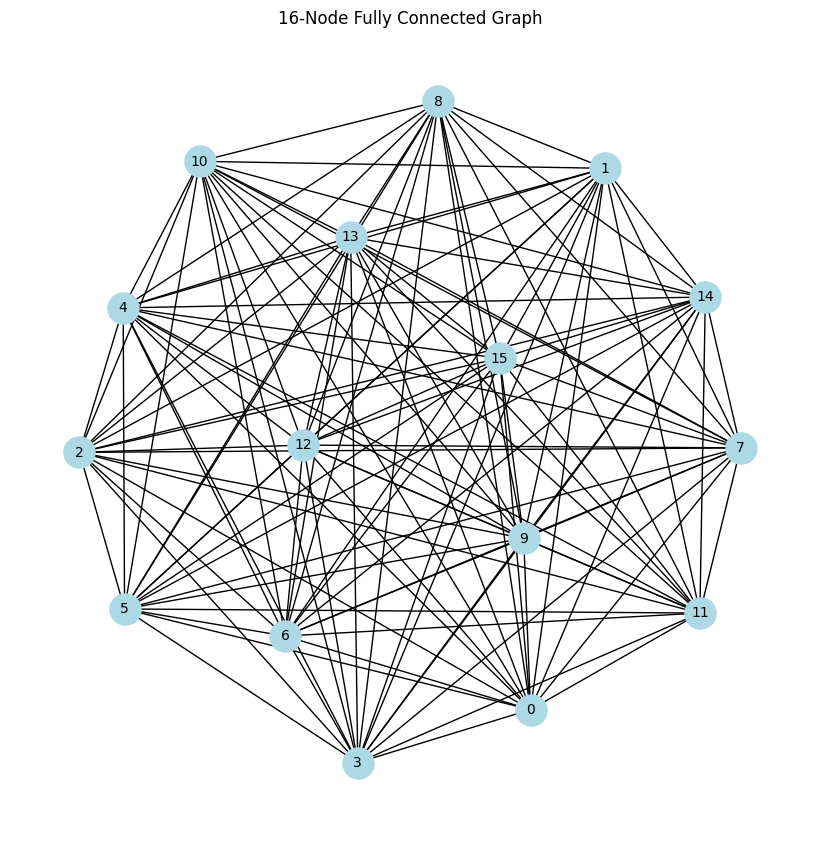

In [ ]:
# prompt: Plot a 16 node graph where every node is connected to every other node except itself

import matplotlib.pyplot as plt
import networkx as nx

# Create a graph with 16 nodes
graph = nx.Graph()
graph.add_nodes_from(range(16))

# Add edges between every pair of nodes except for self-connections
for i in range(16):
    for j in range(i + 1, 16):
        graph.add_edge(i, j)

# Draw the graph
plt.figure(figsize=(8, 8))
nx.draw(graph, with_labels=True, node_color='lightblue', node_size=500, font_size=10)
plt.title("16-Node Fully Connected Graph")
plt.show()


## Setup simulation materials and procedures

In [ ]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
#plt.style.use('seaborn-whitegrid')

### Define autoencoder training (learning function).

In [ ]:
# Function 1: trainnet_hopfield
#-----------------------------------------------------------------
# Trains a weight matrix, W, based on a series of
# training input vectors, a, using the Hopfield
# learning rule W=(2a-1)*t(2a-1).
#
# Usage:
# W<-trainnet_hopfield(W,a)
#
# W - (input)initial weight matrix to be trained (must be square
#     matrix of same dimension as input vector, a.
#   - if W is set to scalar, then an initial W of the scalar value
#     is created based on input vector, a, dimensions.
# a - matrix of training vectors with the units to be
#     train in rows, and the training pattern for each
#     unit in columns.
#
# Note: This only does 2d weight matrices.
# Created by Josh Goh 13 Feb 2007

def trainnet_hopfield(W,a):

  # Initialize weight matrix, W
  if np.size(W)==1:
    W = W*np.ones((np.shape(a)[1],np.shape(a)[1]))

  # Train
  for s in range(np.shape(a)[0]):
    dW = np.outer((2*a[s,:]-1),np.transpose(2*a[s,:]-1))
    W  = W + dW

  # Zero diagonals (units not auto-connected)
  W[np.diag_indices(np.shape(W)[0])] = 0

  return W

### Define autoencoder testing (activation function).

In [ ]:
# Function 2: testnet_hopfield
#--------------------------------------------------------------
# Tests a Hopfield trained weight matrix, W, with an
# input vector pattern, a, for t iterations of consecutive
# zero hamming distances between each activation state.
# Returns a matrix of unit activation changes, a, a vector
# of network energy level changes, e, and a vector of
# hamming distances changes, hd. Flags f=1 if network fails
# to settle, f=0 otherwise.
#
# Usage:
# testnet_hopfield(W,a,t)
#
# W - trained hopfield weight matrix to be tested
# a - test vector pattern; array format
# t - number of iterations of consecutive zero hamming
#     distances desired
#
# Created by Josh Goh 13 Feb 2007

def testnet_hopfield(W,a,t):

  # Initialize parameters
  u = 0 # activation threshold
  e = [0] # energy zero start vector
  hd = [0] # hamming distance zero start vector
  s = 1 # consecutive no-hd-change counter
  r = 0 # run counter
  f = 0 # fail to settle flag, init 0
  #atemp = a.copy() # first activation vector assignment

  # Start testing
  while s <= t:

    # Buffer
    atemp = a.copy()
    #print(a)

    # Randomly select 1 unit (asynchronous)
    i = np.random.randint(0,np.size(atemp),1)
    #print(i)

    # Update unit i using activation function
    #print(np.dot(atemp,W[:,i]))
    atemp[i] = max(np.sign(np.dot(atemp,W[:,i])-u),0)
   # if np.dot(atemp,W[:,i])>u:
   #   atemp[i]=1
   # else:
   #   atemp[i]=0
    #print(atemp)

    # Calculate energy
    e.extend([-0.5*np.dot(np.dot(atemp,W),a)])

    # Calculate hamming distance
    hd.extend([sum(np.absolute(atemp-a))])

    # Reset change counter if hd changed
    if sum(np.absolute(atemp-a))==0:
      s = s+1
    else:
      if r<1000:
        s=1

        # Flag if fail to settle after 1000 runs
      else:
        f=1

    # Update run counter
    a = atemp.copy()
    r = r+1

  return a, e, hd, f


### Define weights plotting

In [ ]:
# prompt: Visualize W as a heatmap using plotly

import plotly.figure_factory as ff
import plotly.graph_objects as go
import numpy as np

def visualize_heatmap_plotly(W):
  """Visualizes a matrix as a heatmap using Plotly.

  Args:
    W: The matrix to visualize.
  """
  fig = go.Figure(data=go.Heatmap(
      z=W,zmin=-8, zmax = 8,
      colorscale='rdbu_r'
  ))

  fig.update_layout(
      title="Weight Matrix (W) Heatmap",
      xaxis_title="Neuron",
      yaxis_title="Neuron",
      height=400, width=400
  )

  fig.show()

### Define energy plotting

In [ ]:
# Plotting setup
def plot_e(e):
  plt.plot(e)
  plt.title("Total energy timecourse")
  plt.xlabel("Iteration")
  plt.ylabel("E")

### Define test input pattern distortion

In [ ]:
# Distort input vectors
def distort_pattern(a,p):

  ap = a.copy()
  for unit in range(np.shape(ap)[0]):
    if np.random.uniform(0,1,1)<=p:
      if ap[unit]==1:
        ap[unit]=0
      else:
        ap[unit]=1

  return ap

### Specify training input patterns, a.

In [ ]:
# Training activation patterns using Walsh functions
a = np.array([[1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
              [1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0],
              [1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0],
              [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]])

### Initiate weights, W.

In [ ]:
W = W*np.ones((16,16)) # Or W = 0

## Run simulation

Examine initial weights.

In [ ]:
visualize_heatmap_plotly(W)

### Train W

In [ ]:
W = trainnet_hopfield(W,a)
visualize_heatmap_plotly(W)

### Distort test input pattern

In [ ]:
test_pattern_no = 3
distortion = 0.4

# Distort input
ap = distort_pattern(a[test_pattern_no],distortion)
ap

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1])

### Test trained W

Input activation pattern                  : [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [0 0 0 0 1 0 0 1 0 1 1 1 0 1 1 1]
Output activation pattern                 : [1 1 0 0 1 1 0 0 1 1 0 0 1 1 0 0]
Hamming distance between output and input : 8


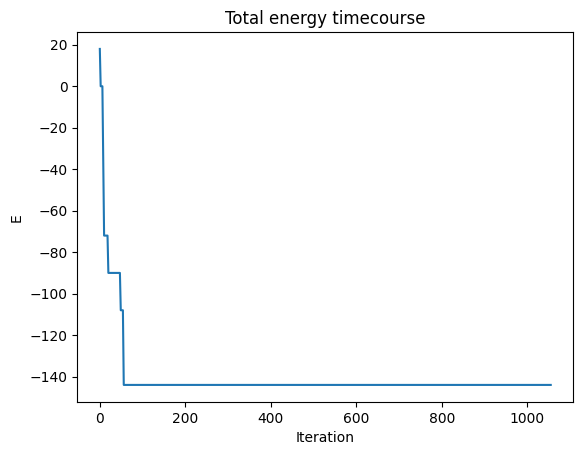

In [ ]:
# Test network
at,e,hd,f = testnet_hopfield(W,ap,1000)
print("Input activation pattern                  :",a[test_pattern_no])
print("Distorted activation pattern              :",ap)
print("Output activation pattern                 :",at)
print("Hamming distance between output and input :",sum(np.absolute(at-a[test_pattern_no])))
plot_e(e[1:])

# Interim Discussion/Conclusion
- Observe how the above autoencoder performs for retrieve Walsh function based on distorted (partial) inputs.
- Does it fulfill content-addressable memory in this case? Why? Why not?
- Other visualizations and/or implementations to improve user interaction for enhancing evaluation?

---

# Simulation 2

What other evaluations, visualizations, applications, or modifications might you try with the above autoencoder?

## Make streamlined evaluation module
Let's put everything above together into an easy to use interface for modifying the base model and evaluating its performance.


### Definitions

In [125]:
# Graph network
def graph_hopfield(k):
  import matplotlib.pyplot as plt
  import networkx as nx

  # Create a graph with 16 nodes
  graph = nx.Graph()
  graph.add_nodes_from(range(k))

  # Add edges between every pair of nodes except for self-connections
  for i in range(k):
      for j in range(i + 1, k):
          graph.add_edge(i, j)

  plt.figure(figsize=(8, 8))
  nx.draw(graph, with_labels=True, node_color='lightblue', node_size=500, font_size=10)
  plt.title("16-Node Fully Connected Graph")
  plt.show()

# Encode (returns W)
def trainnet_hopfield(W,a):

  # Initialize weight matrix, W
  if np.size(W)==1:
    W = W*np.ones((np.shape(a)[1],np.shape(a)[1]))

  # Train
  for s in range(np.shape(a)[0]):
    dW = np.outer((2*a[s,:]-1),np.transpose(2*a[s,:]-1))
    W  = W + dW

  # Zero diagonals (units not auto-connected)
  W[np.diag_indices(np.shape(W)[0])] = 0

  return W

# Retrieve (returns ad, a, e, hd, f)
def testnet_hopfield(W,a,t,u,n_i):

  # Initialize hyperparameters (constraints) and evaluators
  # u, activation threshold
  # t, number of iterations for settling
  # n_i, number of nodes to update each iteration
  e = [0] # energy zero start vector
  hd = [0] # hamming distance zero start vector
  s = 1 # consecutive no-hd-change counter
  r = 0 # run counter
  f = 0 # fail to settle flag, init 0
  ad = [a.copy()] # holding activation array

  # Start testing
  while s <= t:

    # Buffer
    atemp = a.copy()
    #print(a)

    # Randomly select units (asynchronous)
    i = np.random.randint(0,np.size(atemp),n_i)

    # Update unit i using activation function
    for k in i:
      atemp[k] = max(np.sign(np.dot(atemp,W[:,k])-u),0)

    # Calculate energy
    e.extend([-0.5*np.dot(np.dot(atemp,W),a)])

    # Calculate hamming distance
    hd.extend([sum(np.absolute(atemp-a))])

    # Reset change counter if hd changed
    if sum(np.absolute(atemp-a))==0:
      s = s+1
    else:
      if r<1000:
        s=1

        # Flag if fail to settle after 1000 runs
      else:
        f=1

    # Update run counter
    a = atemp.copy()
    ad = np.concatenate((ad,[a]),axis=0)
    r = r+1

  return ad, a, e, hd, f

# Plot weights
def visualize_W_heatmap(W,min,max):
  import plotly.figure_factory as ff
  import plotly.graph_objects as go
  import numpy as np

  fig = go.Figure(data=go.Heatmap(
      z=W,zmin=min, zmax = max,
      colorscale='rdbu_r'
  ))

  fig.update_layout(title="Weight Matrix (W) Heatmap",xaxis_title="Neuron",yaxis_title="Neuron",height=300, width=300)
  fig.show()

# Plot energy
def plot_e(e):
  import matplotlib.pyplot as plt
  plt.figure(figsize=(5,2))
  plt.plot(e)
  plt.title("Total energy timecourse")
  plt.xlabel("Iteration")
  plt.ylabel("E")

# Plot hamming distance
def plot_hd(hd):
  import matplotlib.pyplot as plt
  plt.figure(figsize=(5,2))
  plt.plot(hd)
  plt.title("Hamming distance timecourse")
  plt.xlabel("Iteration")
  plt.ylabel("HD")

# Plot activation transition
def visualize_ad_heatmap(ad):
  import plotly.graph_objects as go
  fig = go.Figure(data=go.Heatmap(z=ad.T, colorscale='gray',showscale=False))
  fig.update_layout(title="Node Matrix (ad) Heatmap",xaxis_title="Iteration",yaxis_title="Neuron",height=250, width=550)
  fig.show()

# Distort input vectors (returns ap)
def distort_pattern(a,p):


  ap = a.copy()
  for unit in range(np.shape(ap)[0]):
    if np.random.uniform(0,1,1)<=p:
      if ap[unit]==1:
        ap[unit]=0
      else:
        ap[unit]=1

  return ap

# Trial report
def report(ad,a,ap,at,test_pattern_no,e):
  print("Input activation pattern                  :",a[test_pattern_no])
  print("Distorted activation pattern              :",ap)
  print("Output activation pattern                 :",at)
  print("Hamming distance between output and input :",sum(np.absolute(at-a[test_pattern_no])))
  plot_e(e[1:])
  plot_hd(hd[1:])
  visualize_ad_heatmap(ad)

# Stat log (returns hdt, min_e_t)
def stats(at,a,e):
  # Hamming distance
  hdt = sum(np.absolute(at-a))

  # Min energy iter
  min_e_t = np.min(np.where(e==np.min(e)))

  return hdt, min_e_t

Input activation pattern                  : [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [1 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0]
Output activation pattern                 : [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
Hamming distance between output and input : 0


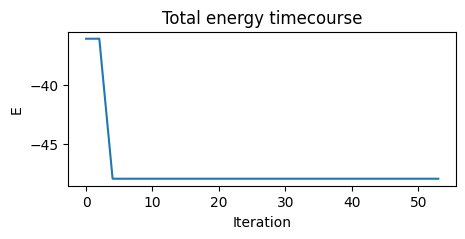

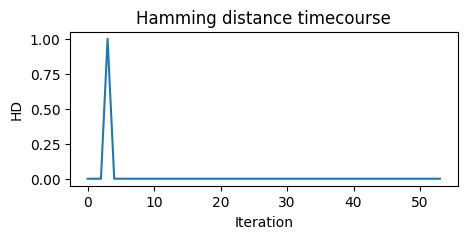

In [70]:
# @title Hopfield app {"run":"auto"}
a = [[1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0], [1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0],[1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0], [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]] # @param {"type":"raw","placeholder":"[[1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],[1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0],[1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0],[1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]]"}
W_recursive = "Yes" # @param ["Yes","No"]
W_learn = "No" # @param ["Yes","No"]
W0 = 0 # @param {"type":"integer"}
test_pattern_no = 3 # @param {"type":"integer"}
distortion = 0.3 # @param {"type":"number"}
n_set_iter = 50 # @param {"type":"integer"}
W_heat_minmax = 4 # @param {"type":"integer","placeholder":"4"}
n_i = 3 # @param {"type":"integer"}
u = -0.5 # @param {"type":"number"}

# SIMULATION
# Initialize
import numpy as np
import matplotlib.pyplot as plt

# Input tokens
a = np.array(a)
#a = np.array([[1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
#              [1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0],
#              [1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0],
#              [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]])

# Train network
if W_recursive=="No":
  W = trainnet_hopfield(W0,a)
elif W_recursive=="Yes" and W_learn=="Yes":
  W = trainnet_hopfield(W,a)
else:
  W = W
visualize_W_heatmap(W,-W_heat_minmax,W_heat_minmax)

# Distort test pattern
ap = distort_pattern(a[test_pattern_no],distortion)

# Test network
ad,at,e,hd,f = testnet_hopfield(W,ap,n_set_iter,u,n_i)

# Report
report(ad,a,ap,at,test_pattern_no,e)

## In Class Challenges:

###1. Statistical evaluation
Evaluate the model performance in terms of accuracy (mean hamming distance) and processing time (mean number of iterations required to reach minimum energy).

[Hint] You will have to modify the Hopfield app to include handling training and testing iterations as well.

Input activation pattern                  : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [1 0 1 0 1 1 1 0 1 0 0 1 1 0 0 0]
Output activation pattern                 : [1 1 1 0 1 1 0 0 1 0 1 0 1 0 0 0]
Hamming distance between output and input : 2


Input activation pattern                  : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Output activation pattern                 : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Hamming distance between output and input : 0


Input activation pattern                  : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [1 1 1 0 1 1 0 0 1 0 1 0 0 0 0 0]
Output activation pattern                 : [1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 0]
Hamming distance between output and input : 6


Input activation pattern                  : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [0 1 0 0 0 1 1 0 1 0 1 0 1 0 1 0]
Output activation pattern                 : [1 1 1 0 1 1 0 0 1 0 1 0 1 0 0 0]
Hamming distance between output and input : 2


Input activation pattern                  : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [1 1 1 0 1 1 1 1 0 0 1 0 1 0 1 0]
Output activation pattern                 : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Hamming distance between output and input : 0


Input activation pattern                  : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [1 1 1 0 1 1 1 0 1 0 1 1 1 0 0 0]
Output activation pattern                 : [1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 0]
Hamming distance between output and input : 6


Input activation pattern                  : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [1 1 1 0 0 1 1 0 1 1 1 0 1 0 1 1]
Output activation pattern                 : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Hamming distance between output and input : 0


Input activation pattern                  : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [1 0 1 0 1 1 1 0 1 0 0 1 1 0 0 1]
Output activation pattern                 : [1 1 1 0 1 1 0 0 1 0 1 0 1 0 0 0]
Hamming distance between output and input : 2


Input activation pattern                  : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 0]
Output activation pattern                 : [1 1 1 1 1 1 0 0 1 1 1 0 1 0 0 0]
Hamming distance between output and input : 4


Input activation pattern                  : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Distorted activation pattern              : [1 1 1 0 1 1 0 1 1 0 1 0 1 1 1 0]
Output activation pattern                 : [1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0]
Hamming distance between output and input : 0


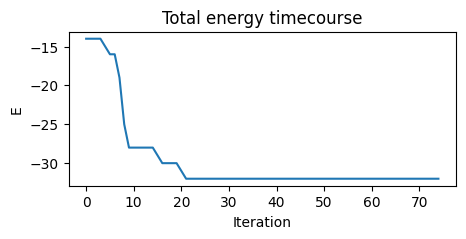

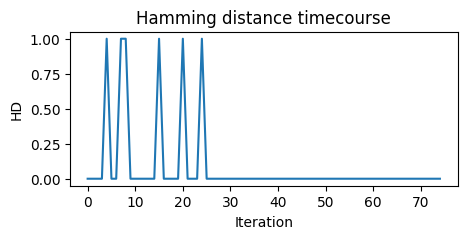

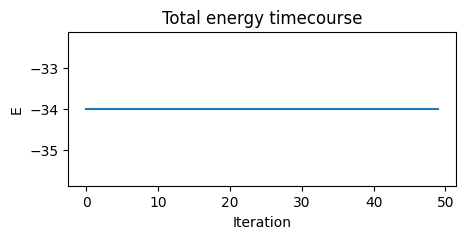

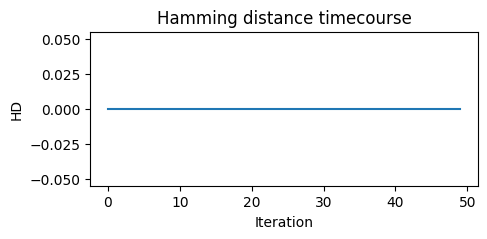

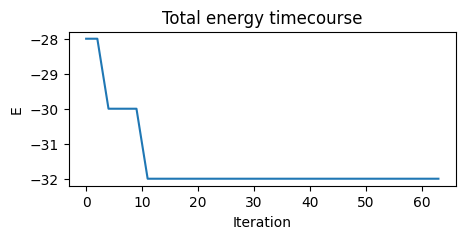

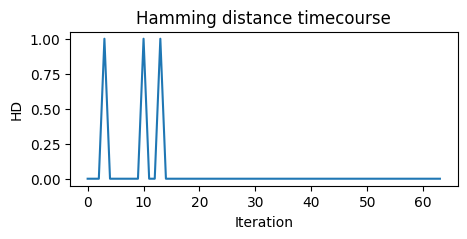

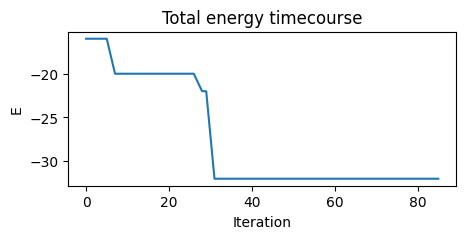

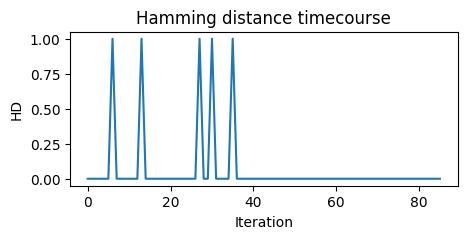

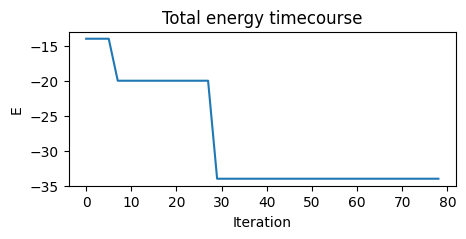

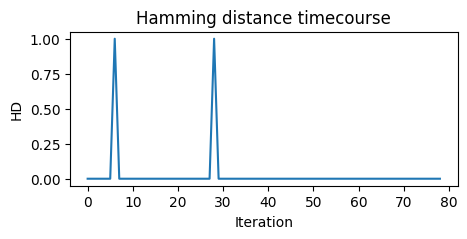

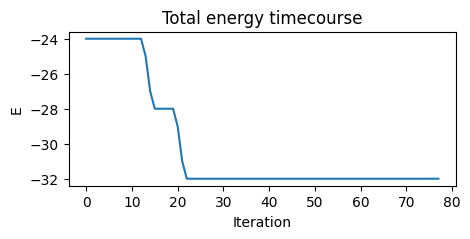

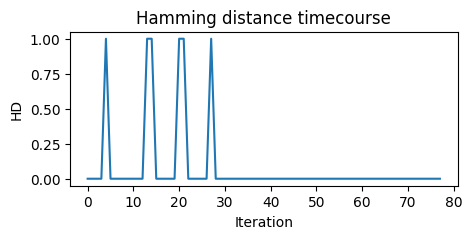

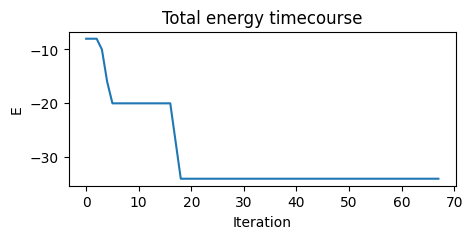

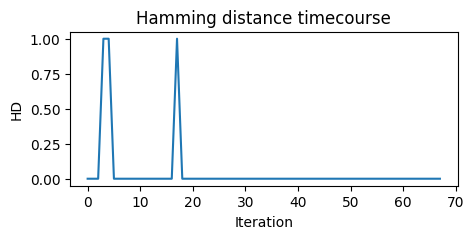

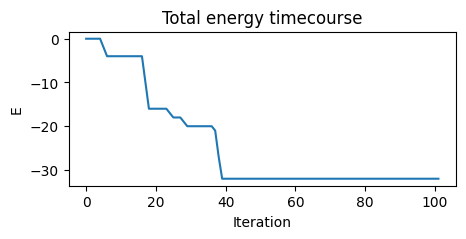

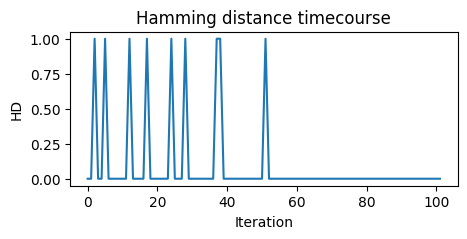

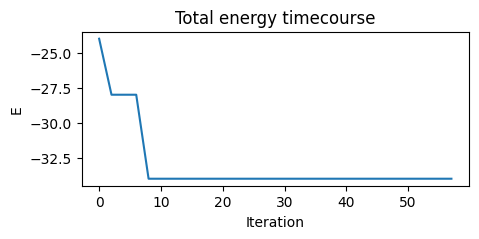

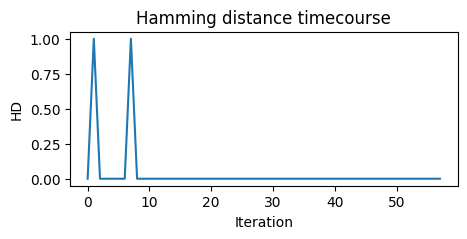

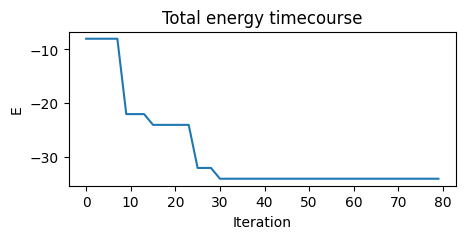

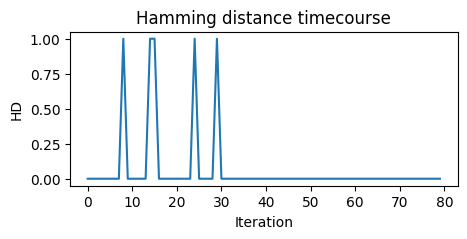

In [126]:
# @title Hopfield (scientist) app (i.e., with test trial looping)
a = [[1,0,1,0,1,1,1,1,0,1,0,1,0,1,0,0], [1,1,1,1,0,1,0,0,1,1,1,1,0,0,0,0],[1,1,0,1,1,1,0,0,1,1,0,0,1,1,0,0], [1,1,1,0,1,1,1,0,1,0,1,0,1,0,1,0]] # @param {"type":"raw","placeholder":"[[1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],[1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0],[1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0],[1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]]"}
W_recursive = "No" # @param ["Yes","No"]
W_learn = "Yes" # @param ["Yes","No"]
W0 = 0 # @param {"type":"integer"}
test_pattern_no = 3 # @param {"type":"integer"}
distortion = 0.2 # @param {"type":"number"}
n_set_iter = 50 # @param {"type":"integer"}
W_heat_minmax = 4 # @param {"type":"integer","placeholder":"4"}
n_i = 1 # @param {"type":"integer"}
u = 0 # @param {"type":"number"}
n_trials = 10 # @param {"type":"integer"}

# SIMULATION
# Initialize
import numpy as np
import matplotlib.pyplot as plt
HDt = [0]
minEt = [0]

# Input tokens
a = np.array(a)

# Train network
if W_recursive=="No":
  W = trainnet_hopfield(W0,a)
elif W_recursive=="Yes" and W_learn=="Yes":
  W = trainnet_hopfield(W,a)
else:
  W = W
visualize_W_heatmap(W,-W_heat_minmax,W_heat_minmax)

# Loop over trials
for trial in np.arange(n_trials):
  # Distort test pattern
  ap = distort_pattern(a[test_pattern_no],distortion)

  # Test network
  ad,at,e,hd,f = testnet_hopfield(W,ap,n_set_iter,u,n_i)

  # Report
  report(ad,a,ap,at,test_pattern_no,e)

  # Log stats
  hdt,min_e_t = stats(at,a[test_pattern_no],e)
  HDt.extend([int(hdt)])
  minEt.extend([int(min_e_t)])



### Data analysis

In [127]:
HDt

[0, 2, 0, 6, 2, 0, 6, 0, 2, 4, 0]

In [128]:
minEt

[0, 22, 1, 12, 32, 30, 23, 19, 40, 9, 31]

###2. Try encoding different set of 4 input tokens

| Input |
| ---|
|1,0,1,0,1,1,1,1,0,1,0,1,0,1,0,0|
|1,1,1,1,0,1,0,0,1,1,1,1,0,0,0,0|
|1,1,0,1,1,1,0,0,1,1,0,0,1,1,0,0|
|1,1,1,0,1,1,1,0,1,0,1,0,1,0,1,0|

Input activation pattern                  : [1 0 1 0 1 1 1 1 0 1 0 1 0 1 0 0]
Distorted activation pattern              : [1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 0]
Output activation pattern                 : [1 0 1 0 1 1 1 1 0 1 0 1 0 1 0 0]
Hamming distance between output and input : 0


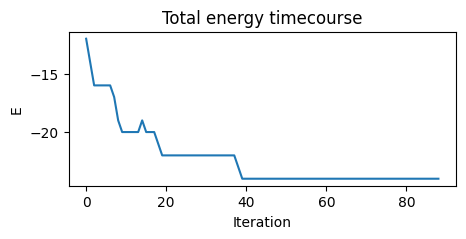

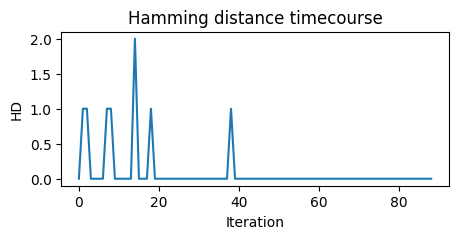

In [109]:
# @title Hopfield (Alice) app {"run":"auto"}
a = [[1,0,1,0,1,1,1,1,0,1,0,1,0,1,0,0], [1,1,1,1,0,1,0,0,1,1,1,1,0,0,0,0],[1,1,0,1,1,1,0,0,1,1,0,0,1,1,0,0], [1,1,1,0,1,1,1,0,1,0,1,0,1,0,1,0]] # @param {"type":"raw","placeholder":"[[1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],[1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0],[1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0],[1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]]"}
W_recursive = "No" # @param ["Yes","No"]
W_learn = "No" # @param ["Yes","No"]
W0 = 0 # @param {"type":"integer"}
test_pattern_no = 0 # @param {"type":"integer"}
distortion = 0.2 # @param {"type":"number"}
n_set_iter = 50 # @param {"type":"integer"}
W_heat_minmax = 4 # @param {"type":"integer","placeholder":"4"}
n_i = 2 # @param {"type":"integer"}
u = 0 # @param {"type":"number"}

# SIMULATION
# Initialize
import numpy as np
import matplotlib.pyplot as plt

# Input tokens
a = np.array(a)
#a = np.array([[1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
#              [1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0],
#              [1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0],
#              [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]])

# Train network
if W_recursive=="No":
  #W = trainnet_hopfield(W0,a)
  Alice = trainnet_hopfield(W0,a)
elif W_recursive=="Yes" and W_learn=="Yes":
  W = trainnet_hopfield(W,a)
else:
  W = W
#visualize_W_heatmap(W,-W_heat_minmax,W_heat_minmax)
visualize_W_heatmap(Alice,-W_heat_minmax,W_heat_minmax)

# Distort test pattern
ap = distort_pattern(a[test_pattern_no],distortion)

# Test network
ad,at,e,hd,f = testnet_hopfield(Alice,ap,n_set_iter,u,n_i)

# Report
report(ad,a,ap,at,test_pattern_no,e)

###3. Try encoding a set of 8 input tokens

| Input |
| ---|
|1,0,1,0,1,1,1,1,0,1,0,1,0,1,0,0|
|0,1,1,1,0,1,0,0,1,1,1,1,0,0,0,0|
|0,1,0,1,1,1,0,0,1,1,0,0,1,1,0,0|
|1,1,1,0,1,1,1,0,1,0,1,0,1,0,1,0|
|1,1,1,1,1,1,1,1,1,0,1,0,1,0,1,1|
|1,1,1,0,1,1,1,0,1,0,1,0,1,0,1,0|
|0,1,1,0,1,1,1,1,1,0,1,0,1,1,1,1|
|0,1,1,0,1,1,1,0,1,1,1,0,1,1,1,0|

###4. How about the identity matrix as the array of tokens?

###5. Start with random weights.

In [ ]:
# prompt: Make a random 16 by 16 array called W

W = np.random.randint(2, size=(16, 16))


###6. Use pre-trained network (W) and try to change it's memory.